<a href="https://colab.research.google.com/github/Project-MANAS-Research-AI/Jansi_Bapodara_Research_AI/blob/main/causal_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install torch torchvision torchaudio transformer-lens matplotlib

In [3]:
import torch
print(torch.__version__)

2.7.1+cu126


In [4]:
pip uninstall torch torchvision torchaudio

Found existing installation: torch 2.7.1
Uninstalling torch-2.7.1:
  Would remove:
    /usr/local/bin/torchfrtrace
    /usr/local/bin/torchrun
    /usr/local/lib/python3.12/dist-packages/functorch/*
    /usr/local/lib/python3.12/dist-packages/torch-2.7.1.dist-info/*
    /usr/local/lib/python3.12/dist-packages/torch/*
    /usr/local/lib/python3.12/dist-packages/torchgen/*
Proceed (Y/n)? y
  Successfully uninstalled torch-2.7.1
Found existing installation: torchvision 0.22.1
Uninstalling torchvision-0.22.1:
  Would remove:
    /usr/local/lib/python3.12/dist-packages/torchvision-0.22.1.dist-info/*
    /usr/local/lib/python3.12/dist-packages/torchvision.libs/libcudart.45e7f3ed.so.12
    /usr/local/lib/python3.12/dist-packages/torchvision.libs/libjpeg.cee450dc.so.8
    /usr/local/lib/python3.12/dist-packages/torchvision.libs/libnvjpeg.e5f20359.so.12
    /usr/local/lib/python3.12/dist-packages/torchvision.libs/libpng16.ca116d9f.so.16
    /usr/local/lib/python3.12/dist-packages/torchvision.li

In [1]:
pip install torch torchvision torchaudio

In [2]:
import torch
import torchaudio

print(torch.__version__)

2.12.1+cu130


In [3]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from transformer_lens import HookedTransformer

In [4]:
model = HookedTransformer.from_pretrained("gpt2-small")
model.eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Loaded pretrained model gpt2-small into HookedTransformer


HookedTransformer(
  (embed): Embed()
  (hook_embed): HookPoint(name='hook_embed')
  (pos_embed): PosEmbed()
  (hook_pos_embed): HookPoint(name='hook_pos_embed')
  (blocks): ModuleList(
    (0): TransformerBlock(
      (ln1): LayerNormPre(
        (hook_scale): HookPoint(name='blocks.0.ln1.hook_scale')
        (hook_normalized): HookPoint(name='blocks.0.ln1.hook_normalized')
      )
      (ln2): LayerNormPre(
        (hook_scale): HookPoint(name='blocks.0.ln2.hook_scale')
        (hook_normalized): HookPoint(name='blocks.0.ln2.hook_normalized')
      )
      (attn): Attention(
        (hook_k): HookPoint(name='blocks.0.attn.hook_k')
        (hook_q): HookPoint(name='blocks.0.attn.hook_q')
        (hook_v): HookPoint(name='blocks.0.attn.hook_v')
        (hook_z): HookPoint(name='blocks.0.attn.hook_z')
        (hook_attn_scores): HookPoint(name='blocks.0.attn.hook_attn_scores')
        (hook_pattern): HookPoint(name='blocks.0.attn.hook_pattern')
        (hook_result): HookPoint(name='blo

In [5]:
clean_prompt = "The capital of France is"
corrupt_prompt = "The capital of India is"

In [6]:
tokens_clean = model.to_tokens(clean_prompt)
tokens_corrupt = model.to_tokens(corrupt_prompt)

In [7]:
print(model.to_str_tokens(tokens_clean))
print(model.to_str_tokens(tokens_corrupt))

['<|endoftext|>', 'The', ' capital', ' of', ' France', ' is']
['<|endoftext|>', 'The', ' capital', ' of', ' India', ' is']


In [8]:
clean_logits,clean_cache= model.run_with_cache(clean_prompt)
clean_cache.keys()

dict_keys(['hook_embed', 'hook_pos_embed', 'blocks.0.hook_resid_pre', 'blocks.0.ln1.hook_scale', 'blocks.0.ln1.hook_normalized', 'blocks.0.attn.hook_q', 'blocks.0.attn.hook_k', 'blocks.0.attn.hook_v', 'blocks.0.attn.hook_attn_scores', 'blocks.0.attn.hook_pattern', 'blocks.0.attn.hook_z', 'blocks.0.hook_attn_out', 'blocks.0.hook_resid_mid', 'blocks.0.ln2.hook_scale', 'blocks.0.ln2.hook_normalized', 'blocks.0.mlp.hook_pre', 'blocks.0.mlp.hook_post', 'blocks.0.hook_mlp_out', 'blocks.0.hook_resid_post', 'blocks.1.hook_resid_pre', 'blocks.1.ln1.hook_scale', 'blocks.1.ln1.hook_normalized', 'blocks.1.attn.hook_q', 'blocks.1.attn.hook_k', 'blocks.1.attn.hook_v', 'blocks.1.attn.hook_attn_scores', 'blocks.1.attn.hook_pattern', 'blocks.1.attn.hook_z', 'blocks.1.hook_attn_out', 'blocks.1.hook_resid_mid', 'blocks.1.ln2.hook_scale', 'blocks.1.ln2.hook_normalized', 'blocks.1.mlp.hook_pre', 'blocks.1.mlp.hook_post', 'blocks.1.hook_mlp_out', 'blocks.1.hook_resid_post', 'blocks.2.hook_resid_pre', 'block

In [9]:
corrupt_logits,corrupt_cache= model.run_with_cache(corrupt_prompt)
corrupt_cache.keys()

dict_keys(['hook_embed', 'hook_pos_embed', 'blocks.0.hook_resid_pre', 'blocks.0.ln1.hook_scale', 'blocks.0.ln1.hook_normalized', 'blocks.0.attn.hook_q', 'blocks.0.attn.hook_k', 'blocks.0.attn.hook_v', 'blocks.0.attn.hook_attn_scores', 'blocks.0.attn.hook_pattern', 'blocks.0.attn.hook_z', 'blocks.0.hook_attn_out', 'blocks.0.hook_resid_mid', 'blocks.0.ln2.hook_scale', 'blocks.0.ln2.hook_normalized', 'blocks.0.mlp.hook_pre', 'blocks.0.mlp.hook_post', 'blocks.0.hook_mlp_out', 'blocks.0.hook_resid_post', 'blocks.1.hook_resid_pre', 'blocks.1.ln1.hook_scale', 'blocks.1.ln1.hook_normalized', 'blocks.1.attn.hook_q', 'blocks.1.attn.hook_k', 'blocks.1.attn.hook_v', 'blocks.1.attn.hook_attn_scores', 'blocks.1.attn.hook_pattern', 'blocks.1.attn.hook_z', 'blocks.1.hook_attn_out', 'blocks.1.hook_resid_mid', 'blocks.1.ln2.hook_scale', 'blocks.1.ln2.hook_normalized', 'blocks.1.mlp.hook_pre', 'blocks.1.mlp.hook_post', 'blocks.1.hook_mlp_out', 'blocks.1.hook_resid_post', 'blocks.2.hook_resid_pre', 'block

In [11]:
answer_token = model.to_single_token(" Paris")

print(answer_token)

6342


In [13]:
clean_answer_logit = clean_logits[0, -1, answer_token]
corrupt_answer_logit = corrupt_logits[0, -1, answer_token]

print("Clean:", clean_answer_logit.item())
print("Corrupt:", corrupt_answer_logit.item())

Clean: 14.320901870727539
Corrupt: 9.10060977935791


In [26]:
import torch

def test_prompt(prompt, answer, model):

    # tokenize prompt
    tokens = model.to_tokens(prompt)

    token_strings = model.to_str_tokens(tokens)

    print("Tokenized prompt:", token_strings)


    # tokenize answer
    answer_tokens = model.to_tokens(answer, prepend_bos=False)

    answer_str = model.to_str_tokens(answer_tokens)

    print("Tokenized answer:", answer_str)


    # run model
    logits = model(tokens)

    # last token prediction
    last_logits = logits[0, -1, :]

    probs = torch.softmax(last_logits, dim=-1)


    # answer token id
    answer_token_id = answer_tokens[0,0].item()


    print("\nPerformance on answer token:")

    print(
        f"Logit: {last_logits[answer_token_id]:.2f} "
        f"Prob: {probs[answer_token_id]*100:.2f}% "
        f"Token: |{answer}|"
    )


    # top predictions
    top_logits, top_tokens = torch.topk(last_logits, 10)


    print("\nTop predictions:")


    for i, (logit, token_id) in enumerate(zip(top_logits, top_tokens)):

        token_id = token_id.item()

        token = model.to_single_str_token(token_id)

        probability = probs[token_id]

        print(
            f"{i}th token. "
            f"Logit: {logit.item():.2f} "
            f"Prob: {probability.item()*100:.2f}% "
            f"Token: |{token}|"
        )


    print("\nRank of answer token:")

    rank = (last_logits > last_logits[answer_token_id]).sum().item() + 1

    print([(answer, rank)])

In [27]:
test_prompt(
    "The capital of France is",
    " Paris",
    model
)

Tokenized prompt: ['<|endoftext|>', 'The', ' capital', ' of', ' France', ' is']
Tokenized answer: [' Paris']

Performance on answer token:
Logit: 11.02 Prob: 0.16% Token: | Paris|

Top predictions:
0th token. Logit: 14.39 Prob: 4.75% Token: | now|
1th token. Logit: 14.15 Prob: 3.74% Token: | the|
2th token. Logit: 14.10 Prob: 3.55% Token: | a|
3th token. Logit: 13.96 Prob: 3.09% Token: | home|
4th token. Logit: 13.82 Prob: 2.70% Token: | in|
5th token. Logit: 13.77 Prob: 2.57% Token: | under|
6th token. Logit: 13.57 Prob: 2.09% Token: | being|
7th token. Logit: 13.42 Prob: 1.80% Token: | set|
8th token. Logit: 13.35 Prob: 1.68% Token: | on|
9th token. Logit: 13.23 Prob: 1.49% Token: | not|

Rank of answer token:
[(' Paris', 93)]


In [34]:
prompt = "The capital city of France is called"

logits = model(prompt)

top_logits, top_tokens = torch.topk(logits[0,-1], 10)

for logit, token in zip(top_logits, top_tokens):
    print(
        model.to_single_str_token(token.item()),
        logit.item()
    )

 Paris 14.320901870727539
 Marse 13.790125846862793
 the 13.780517578125
 " 13.711210250854492
 La 12.986777305603027
 ' 12.684375762939453
 Mont 12.659130096435547
 St 12.603753089904785
 Saint 12.586677551269531
 V 12.299070358276367


The model required completion and clarity in  the sentence. We can also see that it gives better probability for the last prompt therefore I have changed the clean and corrupt prompt to "The capital city of ____ is called"

In [5]:
clean_prompt = "The capital city of France is called"
corrupt_prompt = "The capital city of India is called"

In [6]:
tokens_clean = model.to_tokens(clean_prompt)
tokens_corrupt = model.to_tokens(corrupt_prompt)
print(model.to_str_tokens(tokens_clean))
print(model.to_str_tokens(tokens_corrupt))

['<|endoftext|>', 'The', ' capital', ' city', ' of', ' France', ' is', ' called']
['<|endoftext|>', 'The', ' capital', ' city', ' of', ' India', ' is', ' called']


In [7]:
clean_logits,clean_cache= model.run_with_cache(clean_prompt)
clean_cache.keys()
corrupt_logits,corrupt_cache= model.run_with_cache(corrupt_prompt)
corrupt_cache.keys()

dict_keys(['hook_embed', 'hook_pos_embed', 'blocks.0.hook_resid_pre', 'blocks.0.ln1.hook_scale', 'blocks.0.ln1.hook_normalized', 'blocks.0.attn.hook_q', 'blocks.0.attn.hook_k', 'blocks.0.attn.hook_v', 'blocks.0.attn.hook_attn_scores', 'blocks.0.attn.hook_pattern', 'blocks.0.attn.hook_z', 'blocks.0.hook_attn_out', 'blocks.0.hook_resid_mid', 'blocks.0.ln2.hook_scale', 'blocks.0.ln2.hook_normalized', 'blocks.0.mlp.hook_pre', 'blocks.0.mlp.hook_post', 'blocks.0.hook_mlp_out', 'blocks.0.hook_resid_post', 'blocks.1.hook_resid_pre', 'blocks.1.ln1.hook_scale', 'blocks.1.ln1.hook_normalized', 'blocks.1.attn.hook_q', 'blocks.1.attn.hook_k', 'blocks.1.attn.hook_v', 'blocks.1.attn.hook_attn_scores', 'blocks.1.attn.hook_pattern', 'blocks.1.attn.hook_z', 'blocks.1.hook_attn_out', 'blocks.1.hook_resid_mid', 'blocks.1.ln2.hook_scale', 'blocks.1.ln2.hook_normalized', 'blocks.1.mlp.hook_pre', 'blocks.1.mlp.hook_post', 'blocks.1.hook_mlp_out', 'blocks.1.hook_resid_post', 'blocks.2.hook_resid_pre', 'block

In [8]:
answer_token = model.to_single_token(" Paris")

print(answer_token)
clean_answer_logit = clean_logits[0, -1, answer_token]
corrupt_answer_logit = corrupt_logits[0, -1, answer_token]

print("Clean:", clean_answer_logit.item())
print("Corrupt:", corrupt_answer_logit.item())

6342
Clean: 14.320899963378906
Corrupt: 9.100606918334961


In [9]:
position = 5


def patch_activation(activation, hook):

    activation[:, position, :] = clean_cache[hook.name][:, position, :]

    return activation

In [10]:
patched_logits = model.run_with_hooks(
    corrupt_prompt,
    fwd_hooks=[
        (
            "blocks.0.hook_resid_post",
            patch_activation
        )
    ]
)

In [11]:
patched_answer_logit = patched_logits[0, -1, answer_token]

print("Clean:", clean_answer_logit.item())
print("Corrupt:", corrupt_answer_logit.item())
print("Patched:", patched_answer_logit.item())


Clean: 14.320899963378906
Corrupt: 9.100606918334961
Patched: 14.221320152282715


In [12]:
print(model.to_str_tokens(tokens_clean))
print(model.cfg.n_layers)

['<|endoftext|>', 'The', ' capital', ' city', ' of', ' France', ' is', ' called']
12


In [13]:
n_layers = model.cfg.n_layers
seq_len = tokens_clean.shape[1]

recovery = torch.zeros(n_layers, seq_len)

print(recovery.shape)

torch.Size([12, 8])


In [14]:
with torch.no_grad():

    for layer in range(n_layers):

        for patch_position in range(seq_len):

            patched_logits = model.run_with_hooks(
                corrupt_prompt,
                fwd_hooks=[
                    (
                        f"blocks.{layer}.hook_resid_post",
                        patch_activation
                    )
                ]
            )

            patched_answer_logit = patched_logits[0, -1, answer_token].item()

            recovery[layer, patch_position] = (
                patched_answer_logit - corrupt_answer_logit.item()
            ) / (
                clean_answer_logit.item() - corrupt_answer_logit.item()
            )

            model.reset_hooks()

In [15]:
print(recovery)

tensor([[0.9809, 0.9809, 0.9809, 0.9809, 0.9809, 0.9809, 0.9809, 0.9809],
        [0.9845, 0.9845, 0.9845, 0.9845, 0.9845, 0.9845, 0.9845, 0.9845],
        [0.9736, 0.9736, 0.9736, 0.9736, 0.9736, 0.9736, 0.9736, 0.9736],
        [0.9750, 0.9750, 0.9750, 0.9750, 0.9750, 0.9750, 0.9750, 0.9750],
        [0.9929, 0.9929, 0.9929, 0.9929, 0.9929, 0.9929, 0.9929, 0.9929],
        [0.9974, 0.9974, 0.9974, 0.9974, 0.9974, 0.9974, 0.9974, 0.9974],
        [0.9717, 0.9717, 0.9717, 0.9717, 0.9717, 0.9717, 0.9717, 0.9717],
        [0.9734, 0.9734, 0.9734, 0.9734, 0.9734, 0.9734, 0.9734, 0.9734],
        [0.9578, 0.9578, 0.9578, 0.9578, 0.9578, 0.9578, 0.9578, 0.9578],
        [0.7064, 0.7064, 0.7064, 0.7064, 0.7064, 0.7064, 0.7064, 0.7064],
        [0.5029, 0.5029, 0.5029, 0.5029, 0.5029, 0.5029, 0.5029, 0.5029],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000]])


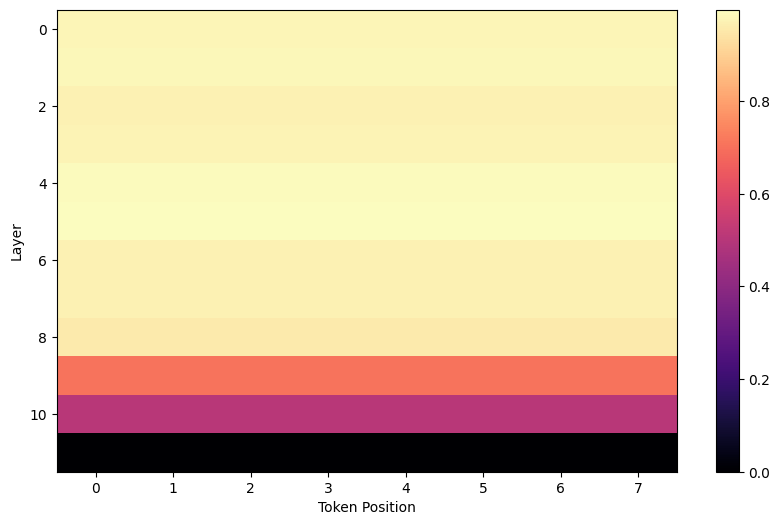

In [16]:
plt.figure(figsize=(10,6))

plt.imshow(
    recovery.detach().numpy(),
    aspect="auto",
    cmap = 'magma'
)

plt.xlabel("Token Position")
plt.ylabel("Layer")
plt.colorbar()

plt.show()

Now since we have a basic layout for 1 sentence, let's explore for more prompts

In [47]:
prompt_pairs = [

    (
        "The author of Harry Potter book series is J. K.",
        "The author of Harry Williams book series is J. K.",
        " Rowling"
    ),

    (
        "The planet known as the Red Planet is",
        "The planet known as the Red Planet is",
        " Mars"
    ),

    (
        "The first month of the year is",
        "The last month of the year is",
        " January"
    ),

    (
        "The currency of USA is the",
        "The currency of Japan is the",
        " Dollar"
    )

]


In [33]:
answer = model.to_str_tokens(" dollar")
print(answer)

['<|endoftext|>', ' dollar']


In [48]:
def run_patching(clean_prompt, corrupt_prompt, answer):

    tokens_clean = model.to_tokens(clean_prompt)

    clean_logits, clean_cache = model.run_with_cache(
        clean_prompt
    )

    corrupt_logits, corrupt_cache = model.run_with_cache(
        corrupt_prompt
    )


    answer_token = model.to_single_token(answer)


    clean_answer_logit = clean_logits[0,-1,answer_token]

    corrupt_answer_logit = corrupt_logits[0,-1,answer_token]


    del clean_logits
    del corrupt_logits


    n_layers = model.cfg.n_layers
    seq_len = tokens_clean.shape[1]


    recovery = torch.zeros(
        n_layers,
        seq_len
    )


    def patch_activation(activation, hook):

        activation[:, patch_position, :] = (
            clean_cache[hook.name][:, patch_position, :]
        )

        return activation



    with torch.no_grad():

        for layer in range(n_layers):

            for patch_position in range(seq_len):


                patched_logits = model.run_with_hooks(

                    corrupt_prompt,

                    fwd_hooks=[
                        (
                            f"blocks.{layer}.hook_resid_post",
                            patch_activation
                        )
                    ]
                )


                patched_answer_logit = (
                    patched_logits[0,-1,answer_token]
                )


                recovery[layer, patch_position] = (

                    patched_answer_logit - corrupt_answer_logit

                ) / (

                    clean_answer_logit - corrupt_answer_logit

                )


                model.reset_hooks()


                del patched_logits


    del clean_cache
    del corrupt_cache

    torch.cuda.empty_cache()


    return recovery

In [49]:
all_recoveries = []


for clean_prompt, corrupt_prompt, answer in prompt_pairs:


    print("Running:", clean_prompt)


    result = run_patching(
        clean_prompt,
        corrupt_prompt,
        answer
    )


    all_recoveries.append(result)


    del result

    torch.cuda.empty_cache()

Running: The author of Harry Potter book series is J. K.
Running: The planet known as the Red Planet is
Running: The first month of the year is
Running: The currency of USA is the


In [50]:
max_len = max(
    r.shape[1] for r in all_recoveries
)


padded_recoveries = []


for r in all_recoveries:

    pad_size = max_len - r.shape[1]

    padded = torch.nn.functional.pad(
        r,
        (0, pad_size)
    )

    padded_recoveries.append(padded)



average_recovery = torch.stack(
    padded_recoveries
).mean(dim=0)


print(average_recovery.shape)

torch.Size([12, 13])


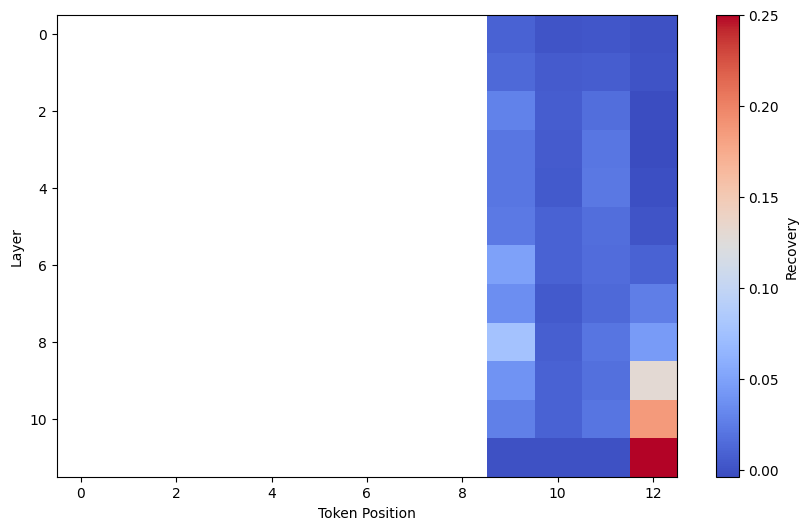

In [51]:
plt.figure(figsize=(10,6))

plt.imshow(
    average_recovery.numpy(),
    aspect="auto",
    cmap= 'coolwarm'
)

plt.xlabel("Token Position")

plt.ylabel("Layer")

plt.colorbar(
    label="Recovery"
)

plt.show()

In [39]:
prompt_pairs = [

    (
        "The capital city of India is called",
        "The capital city of USA is called",
        " Delhi"
    ),

    (
        "The capital city of Italy is called",
        "The capital city of USA is called",
        " Rome"
    ),

    (
        "The capital city of Japan is called",
        "The capital city of India is called",
        " Tokyo"
    )

]

In [41]:
answer = model.to_str_tokens(" Delhi")
print(answer)

['<|endoftext|>', ' Delhi']


In [42]:
def run_patching(clean_prompt, corrupt_prompt, answer):

    tokens_clean = model.to_tokens(clean_prompt)

    clean_logits, clean_cache = model.run_with_cache(
        clean_prompt
    )

    corrupt_logits, corrupt_cache = model.run_with_cache(
        corrupt_prompt
    )


    answer_token = model.to_single_token(answer)


    clean_answer_logit = clean_logits[0,-1,answer_token]

    corrupt_answer_logit = corrupt_logits[0,-1,answer_token]


    del clean_logits
    del corrupt_logits


    n_layers = model.cfg.n_layers
    seq_len = tokens_clean.shape[1]


    recovery = torch.zeros(
        n_layers,
        seq_len
    )


    def patch_activation(activation, hook):

        activation[:, patch_position, :] = (
            clean_cache[hook.name][:, patch_position, :]
        )

        return activation



    with torch.no_grad():

        for layer in range(n_layers):

            for patch_position in range(seq_len):


                patched_logits = model.run_with_hooks(

                    corrupt_prompt,

                    fwd_hooks=[
                        (
                            f"blocks.{layer}.hook_resid_post",
                            patch_activation
                        )
                    ]
                )


                patched_answer_logit = (
                    patched_logits[0,-1,answer_token]
                )


                recovery[layer, patch_position] = (

                    patched_answer_logit - corrupt_answer_logit

                ) / (

                    clean_answer_logit - corrupt_answer_logit

                )


                model.reset_hooks()


                del patched_logits


    del clean_cache
    del corrupt_cache

    torch.cuda.empty_cache()


    return recovery

In [43]:
all_recoveries = []


for clean_prompt, corrupt_prompt, answer in prompt_pairs:


    print("Running:", clean_prompt)


    result = run_patching(
        clean_prompt,
        corrupt_prompt,
        answer
    )


    all_recoveries.append(result)


    del result

    torch.cuda.empty_cache()

Running: The capital city of India is called
Running: The capital city of Italy is called
Running: The capital city of Japan is called


In [44]:
average_recovery = torch.stack(
    all_recoveries
).mean(dim=0)


print(average_recovery.shape)

torch.Size([12, 8])


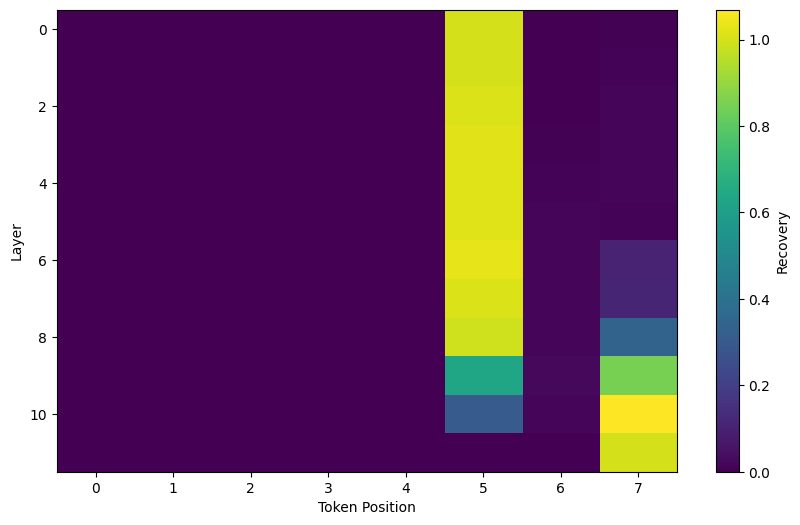

In [45]:
plt.figure(figsize=(10,6))

plt.imshow(
    average_recovery.numpy(),
    aspect="auto"
)

plt.xlabel("Token Position")

plt.ylabel("Layer")

plt.colorbar(
    label="Recovery"
)

plt.show()